In [21]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import importlib
import src.simulator as sim

importlib.reload(sim)

params = sim.SimulationParams()
print(params.tauT)

22.0


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Go to the parent of notebooks/, i.e. your project root
projectRoot = Path.cwd().parent
sys.path.append(str(projectRoot))

from src.simulator import (
    SimulationParams,
    initializePatient,
    simulateSinglePatientDeterministic,
    generateObservations,
    computeConcernScore,
    updateTreatment,
)

In [23]:
params = SimulationParams()

patient = initializePatient(
    severity=0.2,
    infection=0.2,
    respiratoryStress=0.1,
    advocacy=0.5,
)

history = simulateSinglePatientDeterministic(
    initialState=patient,
    params=params,
    numSteps=10,  # increase steps for nicer plots
)

df = pd.DataFrame(history)
df

,step,severity,infection,respiratoryStress,advocacy,treatment,heartRate,respiratoryRate,temperature,concernScore
0,0,0.200000,0.20,0.100000,0.5,0,86.000000,17.400000,37.04,21.632000
1,1,0.221000,0.25,0.122000,0.5,0,86.978000,17.616000,37.10,21.698840
2,2,0.247100,0.30,0.147760,0.5,0,88.047800,17.874960,37.16,21.770953
3,3,0.278488,0.35,0.177586,0.5,0,89.212784,18.179468,37.22,21.848613
4,4,0.315367,0.40,0.211795,0.5,0,90.476611,18.532241,37.28,21.932111
5,5,0.357957,0.45,0.250717,0.5,0,91.843227,18.936132,37.34,22.021755
6,6,0.406493,0.50,0.294695,0.5,0,93.316873,19.394140,37.40,22.117869
7,7,0.461228,0.55,0.344084,0.5,0,94.902098,19.909417,37.46,22.220795
8,8,0.522432,0.60,0.399258,0.5,0,96.603774,20.485275,37.52,22.330898
9,9,0.590395,0.65,0.460604,0.5,0,98.427106,21.125202,37.58,22.448558


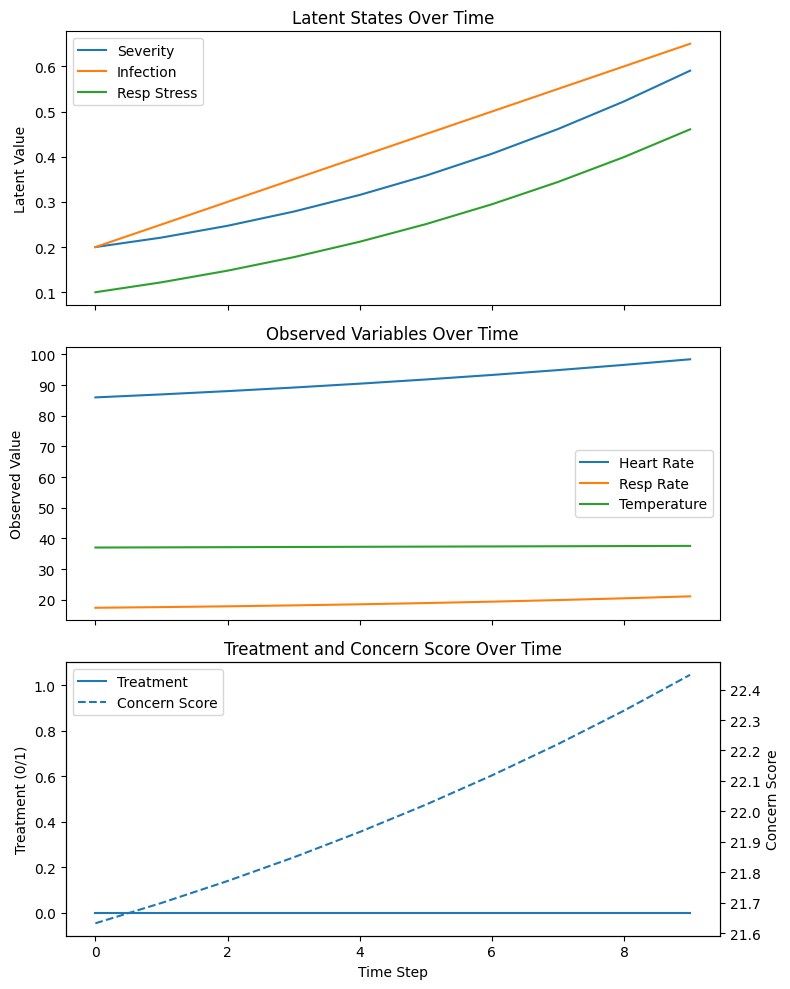

In [24]:
# Create figure with 3 stacked plots
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# -------------------------
# 1. LATENT STATES
# -------------------------
axes[0].plot(df["step"], df["severity"], label="Severity")
axes[0].plot(df["step"], df["infection"], label="Infection")
axes[0].plot(df["step"], df["respiratoryStress"], label="Resp Stress")

axes[0].set_title("Latent States Over Time")
axes[0].set_ylabel("Latent Value")
axes[0].legend()


# -------------------------
# 2. OBSERVED VARIABLES
# -------------------------
axes[1].plot(df["step"], df["heartRate"], label="Heart Rate")
axes[1].plot(df["step"], df["respiratoryRate"], label="Resp Rate")
axes[1].plot(df["step"], df["temperature"], label="Temperature")

axes[1].set_title("Observed Variables Over Time")
axes[1].set_ylabel("Observed Value")
axes[1].legend()


# -------------------------
# 3. TREATMENT + CONCERN SCORE
# -------------------------
axes[2].step(df["step"], df["treatment"], where="post", label="Treatment")
axes[2].set_title("Treatment and Concern Score Over Time")
axes[2].set_ylabel("Treatment (0/1)")
axes[2].set_xlabel("Time Step")
axes[2].set_ylim(-0.1, 1.1)

axConcern = axes[2].twinx()
axConcern.plot(df["step"], df["concernScore"], linestyle="--", label="Concern Score")
axConcern.set_ylabel("Concern Score")

# combine legends
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = axConcern.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc="upper left")



plt.tight_layout()
plt.show()

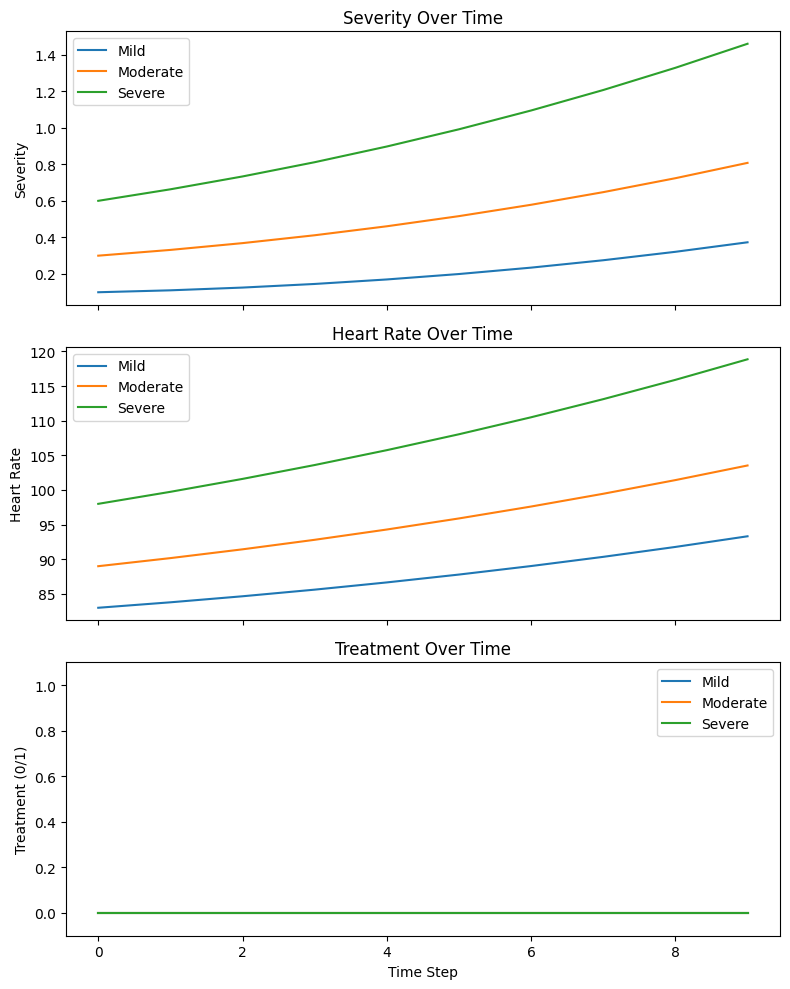

In [ ]:
params = SimulationParams()

patientConfigs = [
    {"label": "Mild", "severity": 0.1, "infection": 0.1, "respiratoryStress": 0.05, "advocacy": 0.0},
    {"label": "Moderate", "severity": 0.35, "infection": 0.35, "respiratoryStress": 0.15, "advocacy": 0.0},
    {"label": "Severe", "severity": 0.6, "infection": 0.6, "respiratoryStress": 0.3, "advocacy": 0.0},
]

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for config in patientConfigs:
    patient = initializePatient(
        severity=config["severity"],
        infection=config["infection"],
        respiratoryStress=config["respiratoryStress"],
        advocacy=config["advocacy"],
    )

    history = simulateSinglePatientDeterministic(
        initialState=patient,
        params=params,
        numSteps=10,
    )

    df = pd.DataFrame(history)

    axes[0].plot(df["step"], df["severity"], label=config["label"])
    axes[1].plot(df["step"], df["heartRate"], label=config["label"])
    axes[2].step(df["step"], df["treatment"], where="post", label=config["label"])

axes[0].set_title("Severity Over Time")
axes[0].set_ylabel("Severity")
axes[0].legend()

axes[1].set_title("Heart Rate Over Time")
axes[1].set_ylabel("Heart Rate")
axes[1].legend()

axes[2].set_title("Treatment Over Time")
axes[2].set_ylabel("Treatment (0/1)")
axes[2].set_xlabel("Time Step")
axes[2].set_ylim(-0.1, 1.1)
axes[2].legend()

plt.tight_layout()
plt.show()

In [28]:
patient = initializePatient(
    severity=0.6,
    infection=0.6,
    respiratoryStress=0.3,
    advocacy=0.0,
)

obs = generateObservations(patient, params)

print("HR =", obs.heartRate)
print("RR =", obs.respiratoryRate)
print("Temp =", obs.temperature)
print("tauT =", params.tauT)
print("concernScore =", computeConcernScore(obs, params))
print("treatment =", updateTreatment(patient, obs, params))

HR = 98.0
RR = 20.2
Temp = 37.519999999999996
tauT = 22.0
concernScore = 22.336
treatment = 1
